Welcome to eht-imaging! v 1.2.10 



/datasets/work/sa-closures-ml/work/CI_ML/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading uvfits:  Diffusion_M87_eht2022_230_thnoise_1.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
No NX table in uvfits!
Loading fits image:  Images/s_sgra.fits


1000it [00:21, 47.06it/s]


Number of Clusters: 5


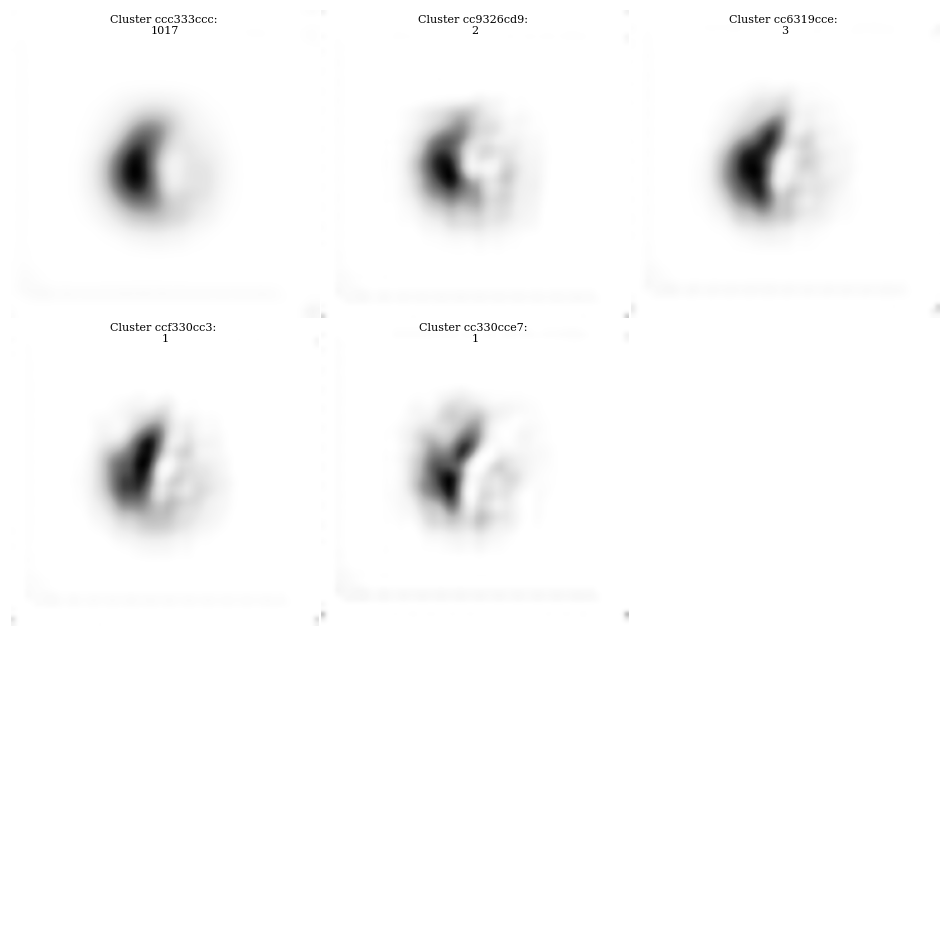

  0%|          | 0/1000 [00:00<?, ?it/s]

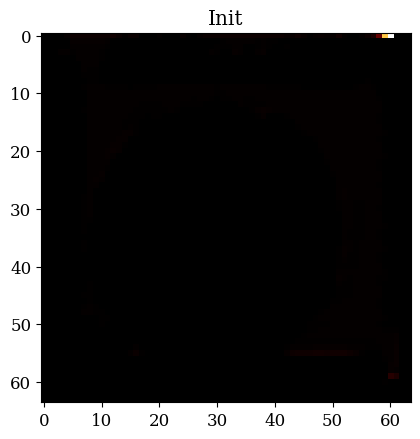

 30%|██▉       | 298/1000 [00:12<00:28, 25.04it/s]

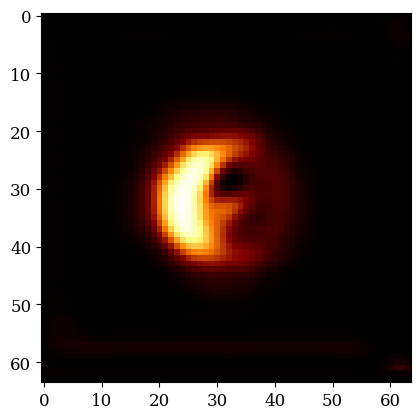

 60%|█████▉    | 598/1000 [00:24<00:15, 25.98it/s]

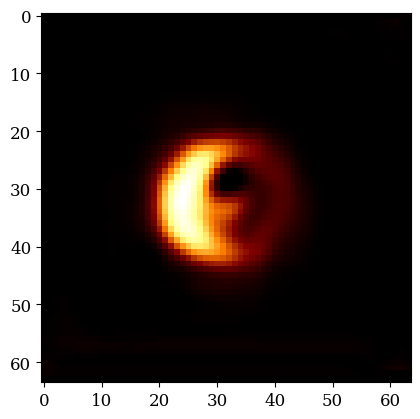

 90%|████████▉ | 898/1000 [00:36<00:04, 24.60it/s]

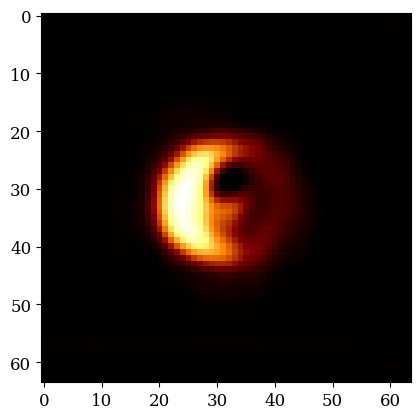

100%|██████████| 1000/1000 [00:40<00:00, 24.42it/s]


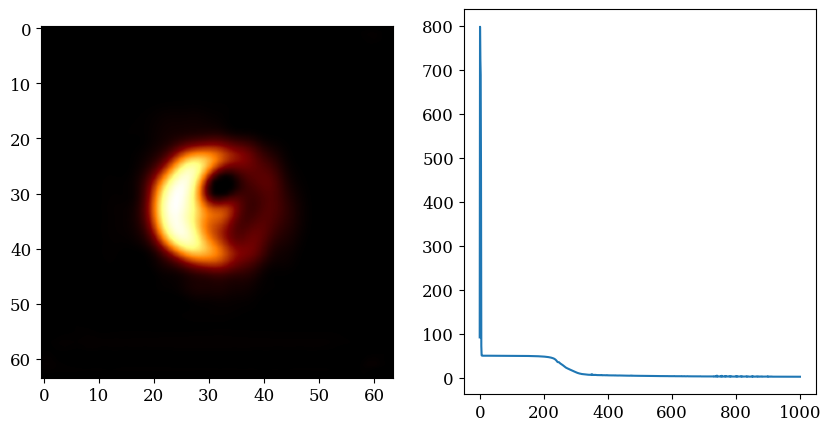

  0%|          | 0/2000 [00:00<?, ?it/s]

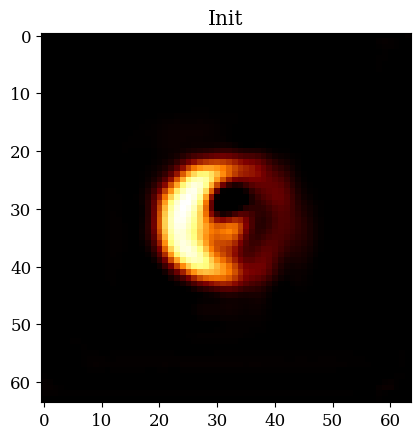

 15%|█▍        | 298/2000 [00:12<01:08, 24.70it/s]

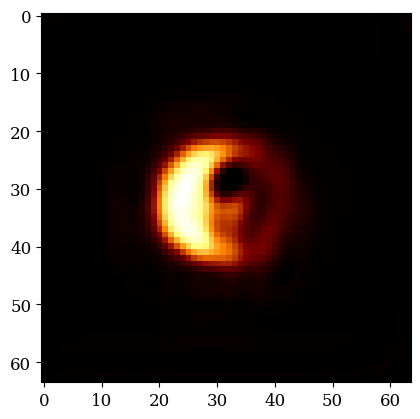

 30%|██▉       | 598/2000 [00:24<00:58, 23.97it/s]

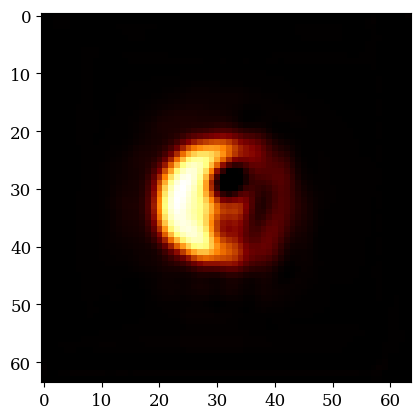

 45%|████▍     | 898/2000 [00:36<00:44, 24.70it/s]

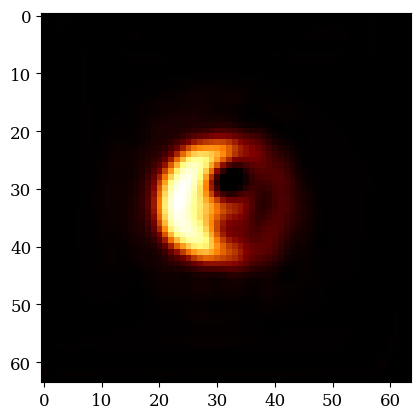

 60%|█████▉    | 1198/2000 [00:49<00:32, 24.57it/s]

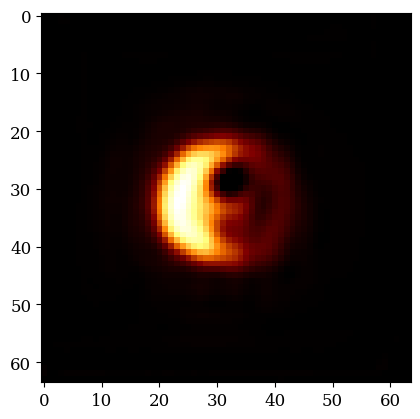

 75%|███████▍  | 1498/2000 [01:01<00:20, 24.22it/s]

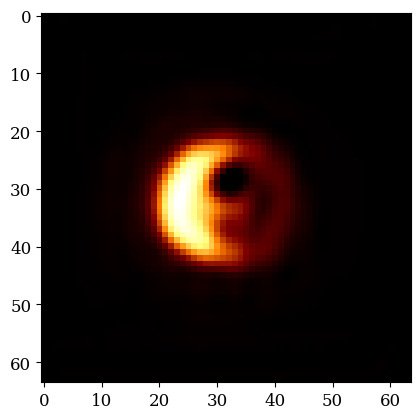

 90%|████████▉ | 1798/2000 [01:13<00:08, 24.45it/s]

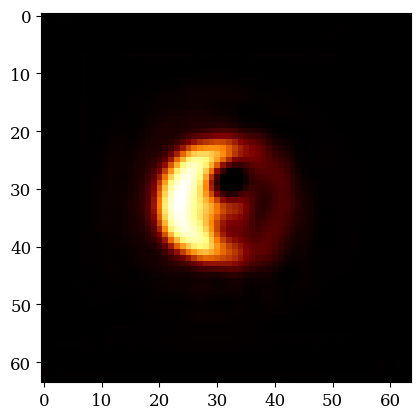

100%|██████████| 2000/2000 [01:21<00:00, 24.42it/s]


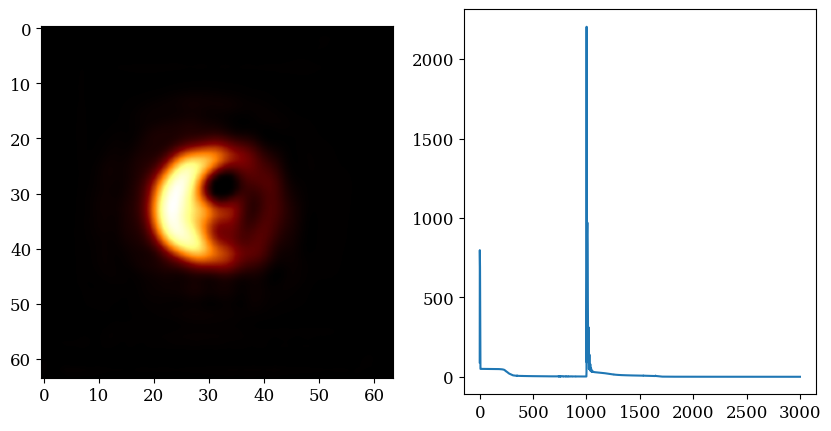

Producing clean visibilities from image with direct FT . . . 


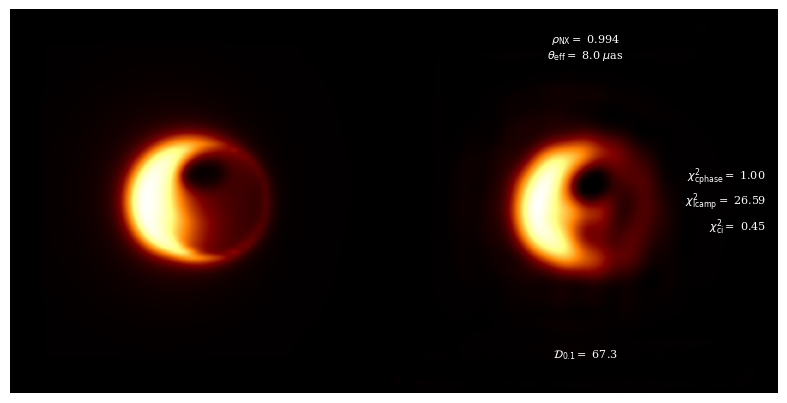

In [2]:
import data.imgTransforms as imgTransforms
import ehtim as eh
import numpy as np
import runGenDIReCT
import torch

tforms = imgTransforms.imgTransforms()

device = "mps" if torch.backends.mps.is_available() else "cuda:1" if torch.cuda.is_available() else "cpu"


model_name = 'Diffusion_M87_eht2022_230_thnoise_1'

model_path = 'models/saved_models/'+model_name+'.pt'
encoder_path = 'models/saved_models/Autoencoders/DIReCT_v2_AEweights.pt'
uvfits_path = 'Diffusion_M87_eht2022_230_thnoise_1.uvfits'

psize = 1.7044214966184275e-11 # the DIReCT psize

imgdim = 64
baseid = 0

model = runGenDIReCT.GenDIReCT(model_path, encoder_path, uvfits_path, device=device, baseid=baseid, imgdim=imgdim, psize=psize)

load_fits = 'Images/s_sgra.fits'


flux = 1.0

img = eh.image.load_fits(load_fits)
img._imdict['I'] = img.imarr().flatten()/np.sum(img.imarr().flatten()) * flux



model.image(img, N_images=1024, useObs=False, add_th_noise=True, th_noise_factor=1.0, 
            add_bl_noise=True, bl_noise_factor=1e-3,
            plot_clusters=True, verbose=True, plot=True)
